
# Titanic Survival Prediction using Decision Tree

This notebook demonstrates:
- Loading the Titanic dataset
- Data cleaning and preprocessing
- Training a Decision Tree classifier
- Evaluating the model
- Visualizing the Decision Tree

Dataset source: Seaborn's built-in Titanic dataset


## What is a Decision Tree Classifier?
A Decision Tree Classifier is a supervised machine learning algorithm used for classification tasks. It works by building a tree-like model of decisions based on the features of the input data. Each internal node in the tree represents a 'test' on an attribute (e.g., 'Is sex male?'), each branch represents the outcome of the test, and each leaf node represents a class label (the decision taken after computing all attributes).

**Key Characteristics:**
*   **Interpretability:** Decision trees are easy to understand and visualize, making them highly interpretable. You can literally see the decision-making process.
*   **Non-parametric:** They make no assumptions about the distribution of the data.
*   **Handles both numerical and categorical data:** They can work with various data types.
*   **Prone to Overfitting:** Without proper pruning or limiting the tree depth, decision trees can easily overfit the training data, leading to poor generalization on unseen data.

In this notebook, we will use a Decision Tree Classifier to predict survival on the Titanic.

In [1]:

# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score



## Load Titanic Dataset
Seaborn provides a clean version of the Titanic dataset.


In [2]:

# Load dataset
df = sns.load_dataset("titanic")

# Preview dataset
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



## Data Cleaning & Feature Selection
- Select relevant features
- Handle missing values
- Encode categorical variables


In [3]:


# Selected features and target
features = ["pclass", "sex", "age", "fare", "embarked"]
target = "survived"

df = df[features + [target]]

# Handle missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Encode categorical columns
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

df.head()

,pclass,sex,age,fare,embarked,survived
0,3,1,22.0,7.2500,2,0
1,1,0,38.0,71.2833,0,1
2,3,0,26.0,7.9250,2,1
3,1,0,35.0,53.1000,2,1
4,3,1,35.0,8.0500,2,0



## Train-Test Split
Split data into training and testing sets.


In [4]:

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## Train Decision Tree Model
We limit tree depth to avoid overfitting.


In [5]:

model = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini",
    min_samples_split=75,
    min_samples_leaf=50,
    random_state=42
)
# min_samples_split prevents splitting nodes with too few samples,
# min_samples_leaf ensures each branch of a split has enough samples
# random_state makes the model's results reproducible.

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=75,
                       random_state=42)

## Confusion Matrix
The confusion matrix shows the number of correct and incorrect predictions made by the classifier compared to the actual outcomes. It helps in understanding the performance of a classification model more comprehensively than just accuracy.

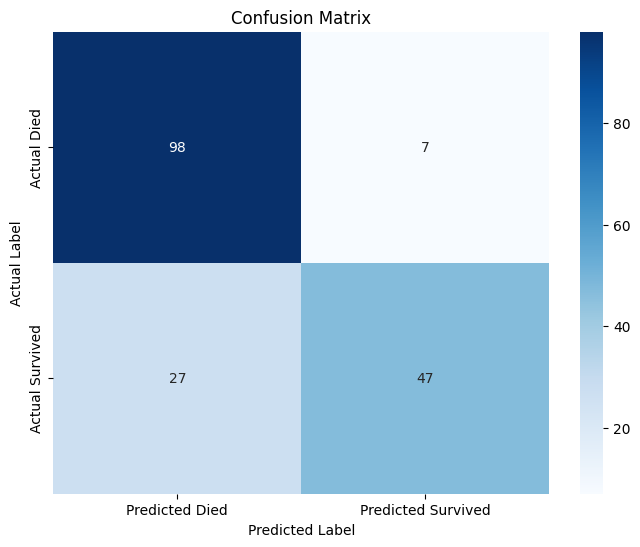

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actual Died', 'Actual Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


## Model Evaluation
Check accuracy on test data.


In [6]:

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8100558659217877


## Visualize Decision Tree
Decision Trees are highly interpretable models.



## Classification Metrics
We evaluate the model using:
- **Precision**: Correct positive predictions out of all positive predictions  
- **Recall**: Correct positive predictions out of all actual positives  
- **F1-score**: Harmonic mean of precision and recall  
- **Support**: Number of actual samples per class


In [7]:

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Died", "Survived"]
))


              precision    recall  f1-score   support

        Died       0.78      0.93      0.85       105
    Survived       0.87      0.64      0.73        74

    accuracy                           0.81       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.82      0.81      0.80       179



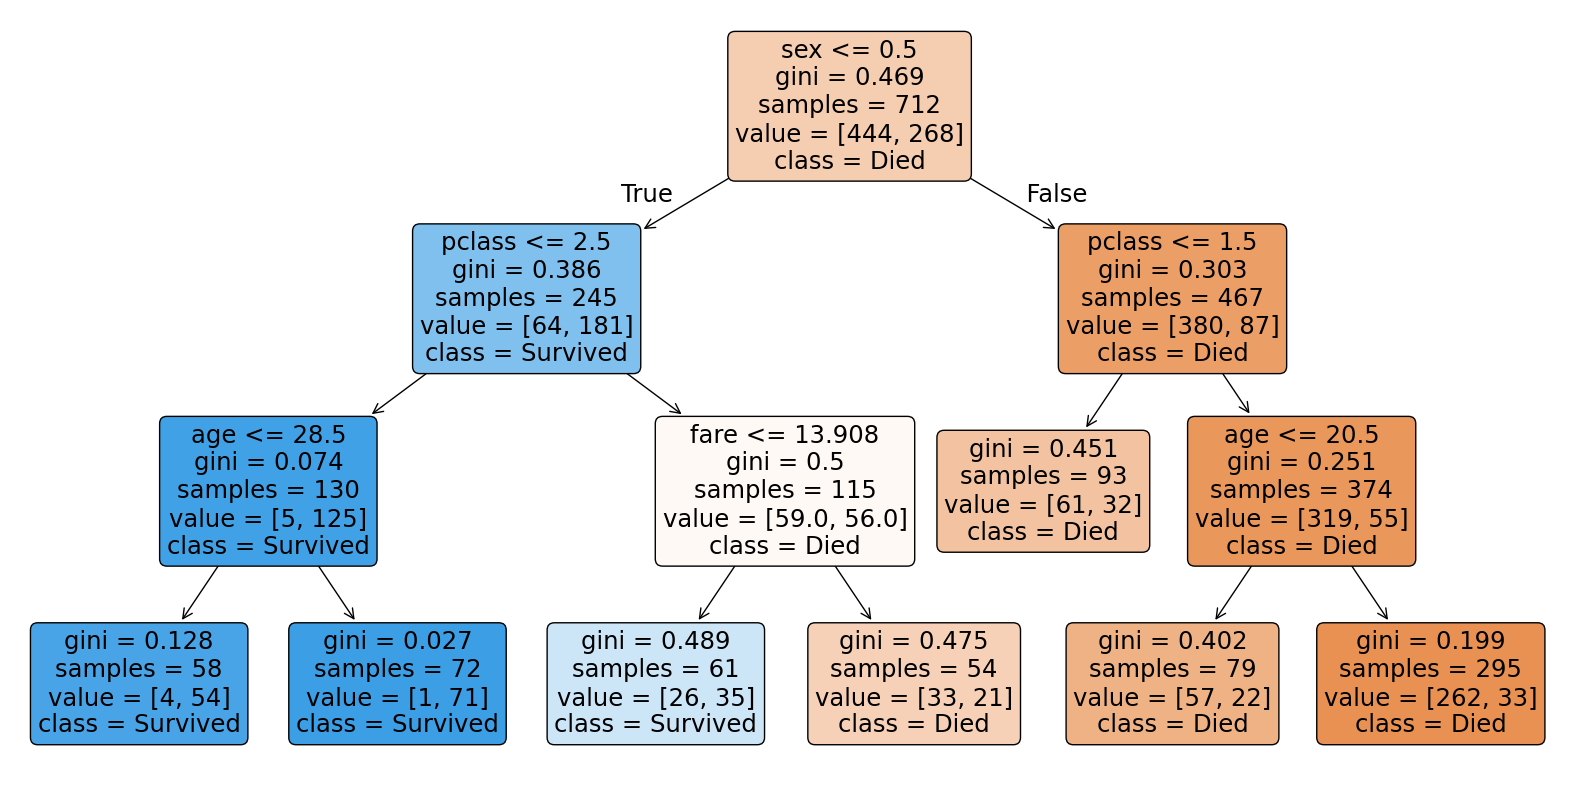

In [8]:

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True
)
plt.show()



## Conclusion
- Sex and passenger class are strong predictors
- Decision Trees are easy to interpret but prone to overfitting
- Ensemble models usually perform better
